In [1]:
# standard libraries
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import multivariate_normal, norm
from scipy import linalg, stats
import time
import importlib
from particles import resampling as rs
from sklearn import metrics
import sys
sys.path.append('..')

import utils as u
importlib.reload(u)

<module 'utils' from '/Users/francescacrucinio/Documents/PAPERS/SUBMITTED/SMC-WFR/TemperedDynamics/../utils.py'>

In [2]:
def gradient_mixture(x, ms, Sigmas, Sigmas_inv, weights):
    gradient = np.zeros(x.shape)
    denominator = np.zeros((weights.size, x.shape[1]))
    for j in range(weights.size):
        denominator[j, :] = weights[j]*multivariate_normal.pdf(x.T, ms[j,:], Sigmas[j,:,:])
        gradient += -denominator[j, :]*np.matmul(Sigmas_inv[j,:,:],(x.T-ms[j,:]).T)
    return gradient/np.sum(denominator, axis = 0)

def logpi_mixture(x, ms, Sigmas, weights):
    logpi = np.zeros((weights.size, x.shape[1]))
    for j in range(weights.size):
        logpi[j, :] = weights[j]*multivariate_normal.pdf(x.T, ms[j,:], Sigmas[j,:,:])
    return np.log(np.sum(logpi, axis = 0))

In [3]:
def TemperedULA(gamma, Niter, ms, Sigmas, Sigmas_inv, weights, X0, lseq):
    d = ms[0,:].size
    N = X0.shape[0]
    X = np.zeros((Niter+1, d, N))
    X[0, :, :] = X0.T
    for i in range(1, Niter+1):
        l = lseq[i-1]
        gradient = l*gradient_mixture(X[i-1, :, :], ms, Sigmas, Sigmas_inv, weights) - (1-l)*X[i-1, :, :]
        X[i, :, :] = X[i-1, :, :] + gamma*gradient + np.sqrt(2*gamma)*np.random.multivariate_normal(np.zeros(d), np.eye(d), size = N).T
    return X

In [4]:
def TemperedULA_adaptive_ess(gamma, Niter, ms, Sigmas, Sigmas_inv, weights, X0):
    d = ms[0,:].size
    N = X0.shape[0]
    X = np.zeros((Niter+1, d, N))
    l = 0
    i = -1
    lambdas = [l]
    while ((l < 1) & (i < Niter)):
        i = i+1
        if (i == 0):
            X[i, :] = X0.T
        else:
            gradient = l*gradient_mixture(X[i-1, :, :], ms, Sigmas, Sigmas_inv, weights) - (1-l)*X[i-1, :, :]
            X[i, :, :] = X[i-1, :, :] + gamma*gradient + np.sqrt(2*gamma)*np.random.multivariate_normal(np.zeros(d), np.eye(d), size = N).T
        l = l + gamma*np.var(-X[i, :, :]**2/2-logpi_mixture(X[i, :, :], ms, Sigmas, weights))**(-1/2)
        
        if (l >= 1): l = 1
        lambdas.append(l)
    for j in range(i+1, Niter):
        lambdas.append(1)
        gradient = gradient_mixture(X[j-1, :, :], ms, Sigmas, Sigmas_inv, weights)
        X[j, :, :] = X[j-1, :, :] + gamma*gradient + np.sqrt(2*gamma)*np.random.multivariate_normal(np.zeros(d), np.eye(d), size = N).T
    return X, lambdas

def TemperedULA_adaptive_gosh(gamma, Niter, ms, Sigmas, Sigmas_inv, weights, X0):
    d = ms[0,:].size
    N = X0.shape[0]
    X = np.zeros((Niter+1, d, N))
    l = 0
    i = -1
    lambdas = [l]
    while ((l < 1) & (i < Niter)):
        i = i+1
        if (i == 0):
            X[i, :] = X0.T
        else:
            gradient = l*gradient_mixture(X[i-1, :, :], ms, Sigmas, Sigmas_inv, weights) - (1-l)*X[i-1, :, :]
            X[i, :, :] = X[i-1, :, :] + gamma*gradient + np.sqrt(2*gamma)*np.random.multivariate_normal(np.zeros(d), np.eye(d), size = N).T
        l = l + gamma*((1-l)*np.var(-X[i, :, :]**2/2-logpi_mixture(X[i, :, :], ms, Sigmas, weights)))**(-1)
        if (l >= 1): l = 1
        lambdas.append(l)
    for j in range(i+1, Niter):
        lambdas.append(1)
        gradient = gradient_mixture(X[j-1, :, :], ms, Sigmas, Sigmas_inv, weights)
        X[j, :, :] = X[j-1, :, :] + gamma*gradient + np.sqrt(2*gamma)*np.random.multivariate_normal(np.zeros(d), np.eye(d), size = N).T
    return X, lambdas


def TemperedULA_adaptive_optimal(gamma, Niter, ms, Sigmas, Sigmas_inv, weights, X0):
    d = ms[0,:].size
    N = X0.shape[0]
    X = np.zeros((Niter+1, d, N))
    l = 0
    i = -1
    lambdas = [l]
    while ((l < 1) & (i < Niter)):
        i = i+1
        if (i == 0):
            X[i, :] = X0.T
        else:
            gradient = l*gradient_mixture(X[i-1, :, :], ms, Sigmas, Sigmas_inv, weights) - (1-l)*X[i-1, :, :]
            X[i, :, :] = X[i-1, :, :] + gamma*gradient + np.sqrt(2*gamma)*np.random.multivariate_normal(np.zeros(d), np.eye(d), size = N).T
        l = l + gamma*(1-l)*np.var(-X[i, :, :]**2/2-logpi_mixture(X[i, :, :], ms, Sigmas, weights))
        if (l >= 1): l = 1
        lambdas.append(l)
    for j in range(i+1, Niter):
        lambdas.append(1)
        gradient = gradient_mixture(X[j-1, :, :], ms, Sigmas, Sigmas_inv, weights)
        X[j, :, :] = X[j-1, :, :] + gamma*gradient + np.sqrt(2*gamma)*np.random.multivariate_normal(np.zeros(d), np.eye(d), size = N).T
    return X, lambdas[:-1]

In [5]:
w = 1/2
sigma = 1
weights = np.array([w, 1-w])

In [6]:
m = 4
d = 1

In [7]:
N = 500
X0 = np.random.multivariate_normal(np.zeros(d), np.eye(d), size = N)
Nrep = 10
Niter = 10000
gamma = 0.01

In [8]:
times_ula = np.zeros((Nrep))
times_tula_ess = np.zeros((Nrep))
times_tula_gosh = np.zeros((Nrep))
times_tula_optimal = np.zeros((Nrep))

mmd_ula = np.zeros((Niter, Nrep))
mmd_tula_ess = np.zeros((Niter, Nrep))
mmd_tula_gosh = np.zeros((Niter, Nrep))
mmd_tula_optimal = np.zeros((Niter, Nrep))

lseq_ess = np.zeros((Niter+1, Nrep))
lseq_gosh = np.zeros((Niter+1, Nrep))
lseq_optimal = np.zeros((Niter+1, Nrep))

In [9]:
ms = np.array([np.zeros(d), m*np.ones(d)])
Sigmas = np.array([sigma*np.eye(d), sigma*np.eye(d)]) 
Sigmas_inv = np.array([linalg.inv(Sigmas[0,:,:]), linalg.inv(Sigmas[1,:,:])])
component = np.random.choice(2, p = weights, size = N)
true_sample = np.zeros((N, d))
for n in range(N):
    true_sample[n, :] = np.random.multivariate_normal(ms[component[n], :], Sigmas[component[n], :, :], size = 1)
for j in range(Nrep):
    # ULA
    start = time.time()
    ula_chain = TemperedULA(gamma, Niter, ms, Sigmas, Sigmas_inv, weights, X0, np.ones(Niter))
    end = time.time()
    times_ula[j] = end-start
    for k in range(Niter):
        mmd_ula[k, j] = u.mmd_rbf(true_sample, ula_chain[k, :, :].T)
    # Tempered ULA ess
    start = time.time()
    tempered_ula_chain_ess, lseq_ess[:, j] = TemperedULA_adaptive_ess(gamma, Niter, ms, Sigmas, Sigmas_inv, weights, X0)
    end = time.time()
    times_tula_ess[j] = end-start
    for k in range(Niter):
        mmd_tula_ess[k, j] = u.mmd_rbf(true_sample, tempered_ula_chain_ess[k, :, :].T)
    # Tempered ULA Gosh
    start = time.time()
    tempered_ula_chain_gosh, lseq_gosh[:, j] = TemperedULA_adaptive_gosh(gamma, Niter, ms, Sigmas, Sigmas_inv, weights, X0)
    end = time.time()
    times_tula_gosh[j] = end-start
    for k in range(Niter):
        mmd_tula_gosh[k, j] = u.mmd_rbf(true_sample, tempered_ula_chain_gosh[k, :, :].T)
    # Tempered ULA ODE
    start = time.time()
    tempered_ula_chain_optimal, lseq_optimal[:, j] = TemperedULA_adaptive_optimal(gamma, Niter, ms, Sigmas, Sigmas_inv, weights, X0)
    end = time.time()
    times_tula_optimal[j] = end-start
    for k in range(Niter):
        mmd_tula_optimal[k, j] = u.mmd_rbf(true_sample, tempered_ula_chain_optimal[k, :, :].T)


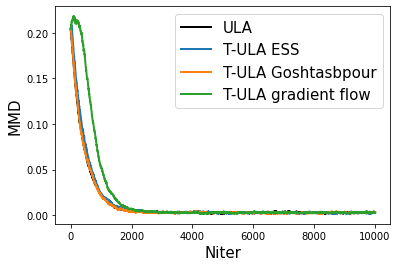

In [12]:
plt.plot(np.mean(mmd_ula, axis = 1), color = 'black', lw = 2, label = 'ULA')
plt.plot(np.mean(mmd_tula_ess, axis = 1), lw = 2, label = 'T-ULA ESS')
plt.plot(np.mean(mmd_tula_gosh, axis = 1), lw = 2, label = 'T-ULA Goshtasbpour')
plt.plot(np.mean(mmd_tula_optimal, axis = 1), lw = 2, label = 'T-ULA gradient flow')

plt.legend(fontsize = 15)
plt.ylabel('MMD', fontsize = 15)
plt.xlabel('Niter', fontsize = 15)
# plt.savefig("gaussian_mix_tempering_m4_mmd.pdf", bbox_inches='tight')

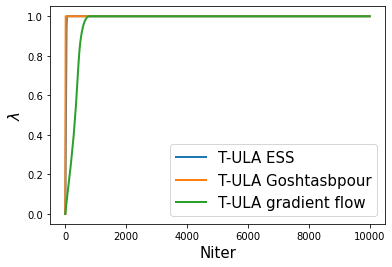

In [14]:
plt.plot(np.mean(lseq_ess, axis = 1), lw = 2, label = 'T-ULA ESS')
plt.plot(np.mean(lseq_gosh, axis = 1), lw = 2, label = 'T-ULA Goshtasbpour')
plt.plot(np.mean(lseq_optimal, axis = 1), lw = 2, label = 'T-ULA gradient flow')

plt.ylabel('$\lambda$', fontsize = 15)
plt.xlabel('Niter', fontsize = 15)

plt.legend(fontsize = 15)
# plt.savefig("gaussian_mix_tempering_m4_lambda.pdf", bbox_inches='tight')